## Pneumonia Detection on X-RAY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import os

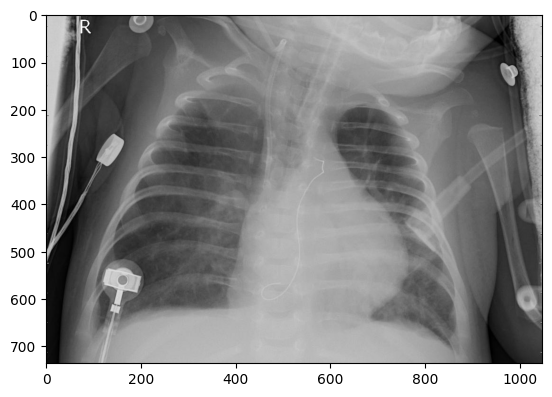

In [2]:
path = "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/train/PNEUMONIA"
img = cv2.imread(os.path.join(path, os.listdir(path)[0]))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

In [5]:
train_generator = train_datagen.flow_from_directory(
    "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/train/",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

Found 5216 images belonging to 2 classes.


In [9]:
test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

test_generator = test_datagen.flow_from_directory(
    "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/test/",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

Found 624 images belonging to 2 classes.


In [10]:
val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_generator = val_datagen.flow_from_directory(
    "/Users/baptistehernette/Documents/Pneumonia_detection/data/chest_xray/val/",
    target_size=(224, 224),
    batch_size=32,
    class_mode="binary"
)

Found 16 images belonging to 2 classes.


In [11]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [12]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

/opt/miniconda3/envs/pneumonia/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


2025-09-08 12:06:37.787608: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


163/163 ━━━━━━━━━━━━━━━━━━━━ 49s 281ms/step - accuracy: 0.6674 - loss: 1.8977 - val_accuracy: 0.4375 - val_loss: 2.0819
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 266ms/step - accuracy: 0.7985 - loss: 0.4319 - val_accuracy: 0.6875 - val_loss: 1.6249
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 260ms/step - accuracy: 0.7949 - loss: 0.4758 - val_accuracy: 0.5625 - val_loss: 1.7454
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 256ms/step - accuracy: 0.8092 - loss: 0.3948 - val_accuracy: 0.6250 - val_loss: 1.3554
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 42s 258ms/step - accuracy: 0.8497 - loss: 0.3352 - val_accuracy: 0.6875 - val_loss: 1.2308
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 43s 264ms/step - accuracy: 0.8608 - loss: 0.3171 - val_accuracy: 0.6250 - val_loss: 1.7607
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 44s 267ms/step - accuracy: 0.8725 - loss: 0.3050 - val_accuracy: 0.5625 - val_loss: 1.1654
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 45s 273ms/step - accuracy: 0.8606 - loss: 0.4927 - val

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(test_generator)
print(classification_report(test_generator.classes, y_pred.round()))

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 211ms/step
              precision    recall  f1-score   support

           0       0.34      0.06      0.10       234
           1       0.62      0.93      0.75       390

    accuracy                           0.60       624
   macro avg       0.48      0.50      0.42       624
weighted avg       0.52      0.60      0.50       624

